In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [24]:
rng = np.random.default_rng(23)

# Gillespie Algorithm

In [153]:
def coeff(xs, vsr):
    br = math.factorial(xs) / math.factorial(xs - vsr)
    return br

In [155]:
def gillespie(stoch_inp, stoch_out, rates, tmax):

    # size
    R, S = stoch_inp.shape

    # reaction changes
    stoch = stoch_out - stoch_inp

    # initialization
    t = 0
    x = np.zeros(S)
    path = [x]
    path_times = [0]

    # convert to int
    x = x.astype(np.int64)
    stoch = stoch.astype(np.int64)
    stoch_inp = stoch_inp.astype(np.int64)

    # simulate for burn in and intervals between samples
    while t < tmax:

        # compute reaction propensities ----------------------------------------
        props = np.zeros(R)

        # for each reaction
        for r in range(R):

            # inital rate
            ar = rates[r]

            # for each species
            for s in range(S):
                
                # not involved
                if stoch_inp[r, s] == 0:
                    continue

                # not enough
                if x[s] < stoch_inp[r, s]:
                    ar = 0
                    continue

                # otherwise: multiply rate component
                ar *= coeff(x[s], stoch_inp[r, s])

            # set propensity
            props[r] = ar

        # overall propensity
        a0 = np.sum(props)

        # holding time ---------------------------------------------------------
        t_hold = -np.log(rng.uniform()) / a0
        t += t_hold
        path_times.append(t)

        # next reaction --------------------------------------------------------
        r = rng.choice(range(R), p=props / a0)
        x += stoch[r, :]
        path.append(list(x))

    # convert to array
    path = np.array(path)
    path_times = np.array(path_times)

    return path, path_times

In [156]:
def uniform_time_samples(path, path_times, tmin, tint):

    # size
    _, S = path.shape

    # take n samples at regular intervals after burn in
    n = (tmax - tmin) // tint
    print(f"Taking {n} uniform time samples")

    # store
    sampled_path = np.zeros((n, S))

    # for each time find state of step function
    t_sample = tmin
    for i in range(n):
        mask = (path_times < t_sample)
        sampled_path[i, :] = path[mask, :][-1, :]
        t_sample += tint

    return sampled_path

In [161]:
def plot_path(path):
    
    # size
    _, S = path.shape

    # plot
    fig, axs = plt.subplots()

    # show each species
    for s in range(S):
        if s == 0: label = "miRNA"
        else: label = f"Target mRNA {s + 1}"
        axs.plot(path[:, s], label=label)

    # plot
    axs.set_xlabel("Time")
    axs.set_ylabel("Molecule count")
    axs.set_title("Gillespie simulation of reaction")
    axs.legend()
    plt.show()

In [211]:
def correlation_point(path):

    _, S = path.shape

    corr = np.corrcoef(path.T)[np.triu_indices(S, 1)]

    corr_miRNA = corr[:S - 1]
    corr_mRNA = corr[S - 1:]

    return corr_miRNA, corr_mRNA

In [206]:
def correlation_bootstrap(path, resamples=1000, confidence=0.95):

    alpha = 1 - confidence
    n, S = path.shape

    estimates = np.zeros((resamples, S, S))
    for i in range(resamples):

        idxs = rng.choice(n, size=n)
        path_boot = path[idxs, :]

        estimates[i, :, :] = np.corrcoef(path_boot.T)

    intervals = np.nanquantile(estimates, [(alpha / 2), 1 - (alpha / 2)], axis=0)

    lb = intervals[0, :, :]
    ub = intervals[1, :, :]

    lb_triu = lb[np.triu_indices(S, 1)]
    ub_triu = ub[np.triu_indices(S, 1)]

    corr_miRNA = np.zeros((2, S - 1))
    corr_miRNA[0, :] = lb_triu[:S - 1]
    corr_miRNA[1, :] = ub_triu[:S - 1]

    corr_mRNA = np.zeros((2, int((S - 1) * (S - 2) / 2)))
    corr_mRNA[0, :] = lb_triu[S - 1:]
    corr_mRNA[1, :] = ub_triu[S - 1:]

    return corr_miRNA, corr_mRNA

# M + R -> 0

In [260]:
targets = 10

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
stoch_inp[1, 0] = 1

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    stoch_inp[r + 1, s] = 1

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1

In [ ]:
tmax = 10000

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

In [262]:
tmin = 10
tint = 10

sampled_path = uniform_time_samples(path, path_times, tmin, tint)

Taking 999 uniform time samples


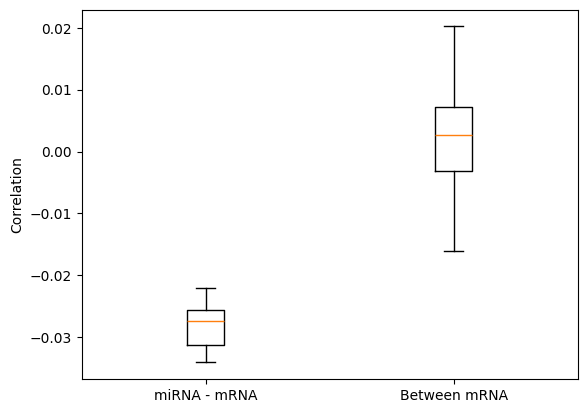

In [264]:
# sampling at reaction times
corr_miRNA, corr_mRNA = correlation_point(path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

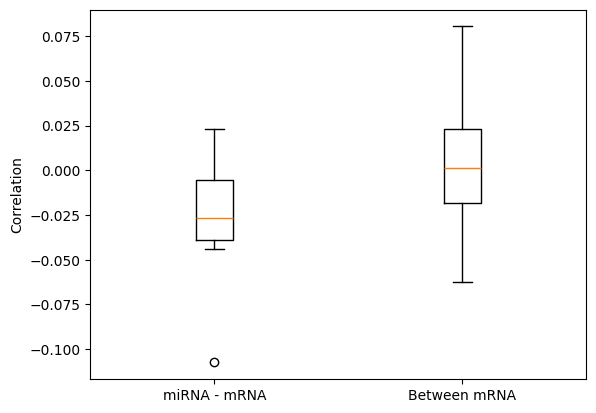

In [265]:
# samping at uniform times
corr_miRNA, corr_mRNA = correlation_point(sampled_path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

In [252]:
# bootstrap CIs
#corr_int_miRNA, corr_int_mRNA = correlation_bootstrap(path)

# correlation between miRNA and targets
#print(corr_int_miRNA)

# correlation between mRNA
#print(corr_int_mRNA)

## Stronger interaction

In [271]:
targets = 10

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
stoch_inp[1, 0] = 1

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    stoch_inp[r + 1, s] = 1

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    rates[r + 2] = 5

In [272]:
tmax = 10000

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

In [273]:
tmin = 10
tint = 10

sampled_path = uniform_time_samples(path, path_times, tmin, tint)

Taking 999 uniform time samples


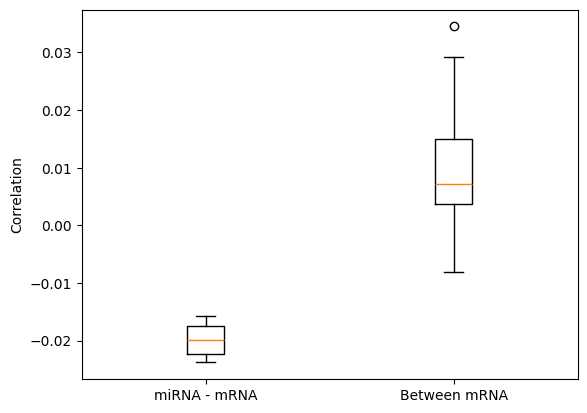

In [274]:
# sampling at reaction times
corr_miRNA, corr_mRNA = correlation_point(path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

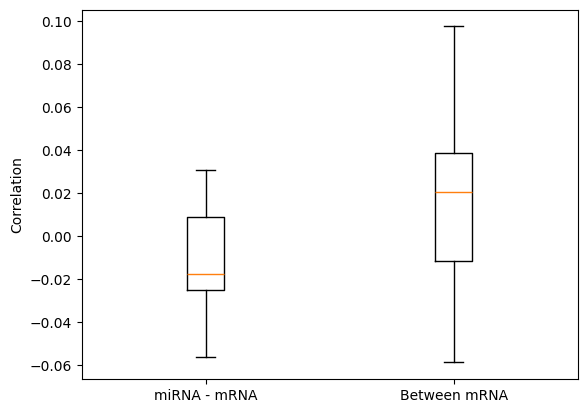

In [275]:
# samping at uniform times
corr_miRNA, corr_mRNA = correlation_point(sampled_path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

### Range

In [312]:
strength_list = [1, 2, 3, 5, 10]
data = {
    'corr_miRNA': [],
    'corr_mRNA': [],
    'sampled_corr_miRNA': [],
    'sampled_corr_mRNA': [],
}
targets = 3

for strength in strength_list:

    stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
    stoch_out = np.zeros((2 + targets * 3, 1 + targets))
    rates = np.ones(2 + 3 * targets)

    # miRNA tx and deg reactions
    stoch_out[0, 0] = 1
    stoch_inp[1, 0] = 1

    for m in range(targets):

        r = 2 + 3 * m
        s = 1 + m

        # mRNA tx and deg reactions
        stoch_out[r, s] = 1
        stoch_inp[r + 1, s] = 1

        # miRNA - mRNA interaction
        stoch_inp[r + 2, 0] = 1
        stoch_inp[r + 2, s] = 1
        rates[r + 2] = strength

    tmax = 10000
    tmin = 10
    tint = 10

    path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)
    sampled_path = uniform_time_samples(path, path_times, tmin, tint)

    corr_miRNA, corr_mRNA = correlation_point(path)
    sampled_corr_miRNA, sampled_corr_mRNA = correlation_point(sampled_path)

    data['corr_miRNA'].append(corr_miRNA)
    data['corr_mRNA'].append(corr_mRNA)
    data['sampled_corr_miRNA'].append(sampled_corr_miRNA)
    data['sampled_corr_mRNA'].append(sampled_corr_mRNA)

Taking 999 uniform time samples
Taking 999 uniform time samples
Taking 999 uniform time samples
Taking 999 uniform time samples
Taking 999 uniform time samples


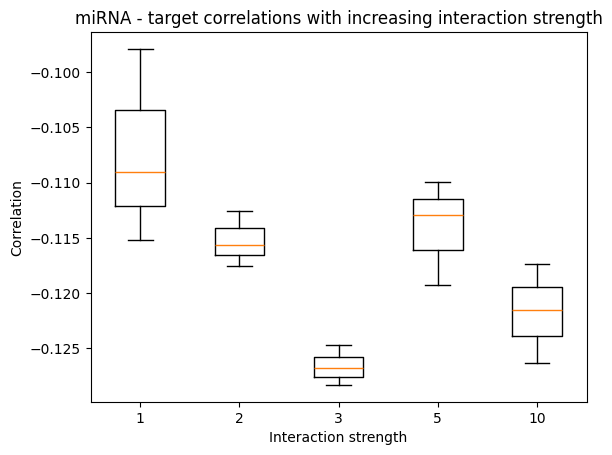

In [313]:
fig, axs = plt.subplots()
axs.boxplot(
    data['corr_miRNA'],
    positions=list(range(len(strength_list)))
)
axs.set_xticklabels(strength_list)
axs.set_xlabel("Interaction strength")
axs.set_ylabel("Correlation")
axs.set_title("miRNA - target correlations with increasing interaction strength")
plt.show()

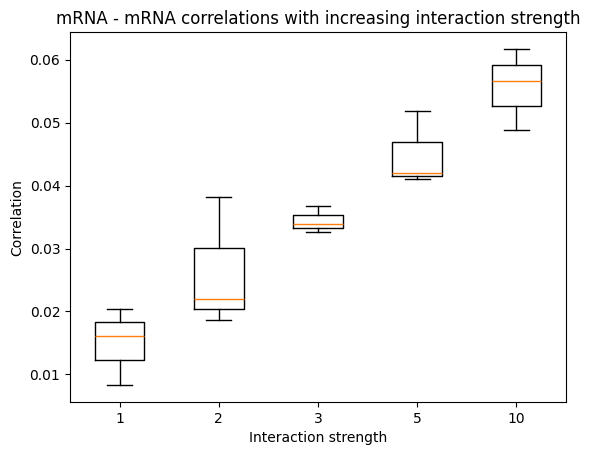

In [314]:
fig, axs = plt.subplots()
axs.boxplot(
    data['corr_mRNA'],
    positions=list(range(len(strength_list)))
)
axs.set_xticklabels(strength_list)
axs.set_xlabel("Interaction strength")
axs.set_ylabel("Correlation")
axs.set_title("mRNA - mRNA correlations with increasing interaction strength")
plt.show()

## Faster miRNA timescale

- significantly increase miRNA tx and deg rates, but keep ratio constant
- means same mean expression level, but returns to this level much faster

In [276]:
targets = 10

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
stoch_inp[1, 0] = 1
rates[0] = 10
rates[1] = 10

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    stoch_inp[r + 1, s] = 1

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1

In [277]:
tmax = 10000

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

In [278]:
tmin = 10
tint = 10

sampled_path = uniform_time_samples(path, path_times, tmin, tint)

Taking 999 uniform time samples


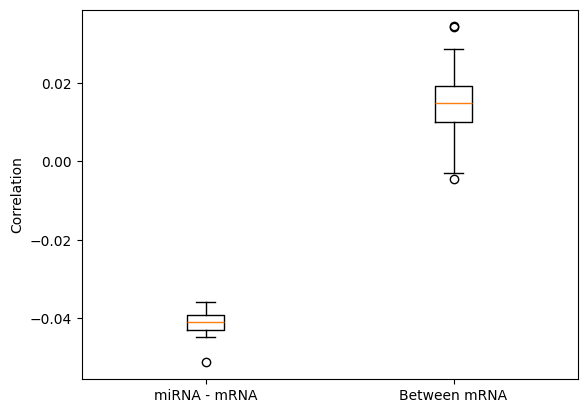

In [279]:
# sampling at reaction times
corr_miRNA, corr_mRNA = correlation_point(path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

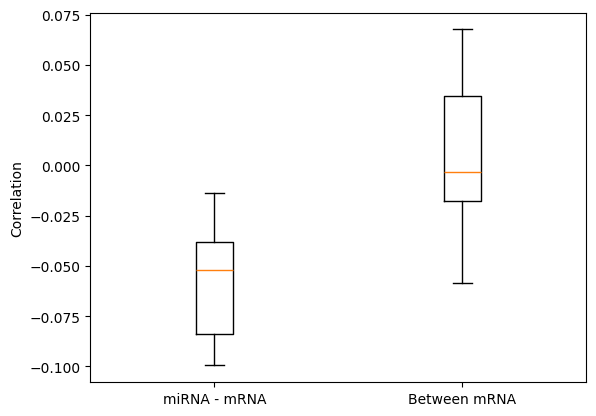

In [280]:
# samping at uniform times
corr_miRNA, corr_mRNA = correlation_point(sampled_path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

In [282]:
np.mean(path, axis=0)

array([0.90061511, 0.64876179, 0.64619332, 0.65192553, 0.64760432,
       0.65656365, 0.65754199, 0.6586526 , 0.65264756, 0.64519845,
       0.64463074])

In [283]:
np.mean(sampled_path, axis=0)

array([0.63663664, 0.65765766, 0.60760761, 0.65965966, 0.61461461,
       0.59259259, 0.62962963, 0.64764765, 0.65265265, 0.64364364,
       0.67667668])

## Higher miRNA expression level

- increase transcription rate of miRNA
- maybe less realistic than faster timescale as if anything observe lower miRNA expression levels

In [284]:
targets = 10

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
stoch_inp[1, 0] = 1
rates[0] = 10

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    stoch_inp[r + 1, s] = 1

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1

In [285]:
tmax = 10000

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

In [286]:
tmin = 10
tint = 10

sampled_path = uniform_time_samples(path, path_times, tmin, tint)

Taking 999 uniform time samples


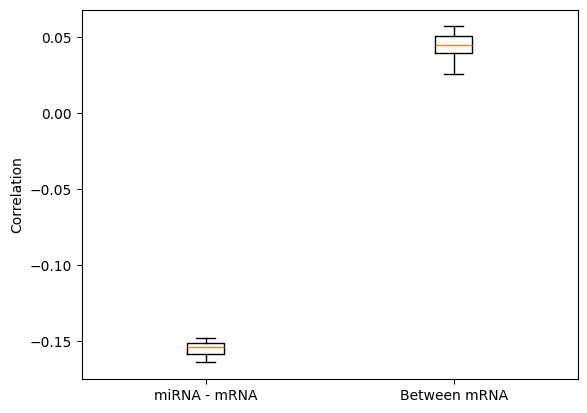

In [287]:
# sampling at reaction times
corr_miRNA, corr_mRNA = correlation_point(path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

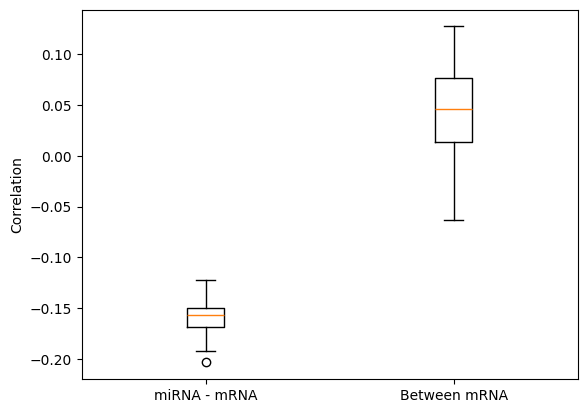

In [288]:
# samping at uniform times
corr_miRNA, corr_mRNA = correlation_point(sampled_path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

## Correlation relationship to # targets

- see how correlation changes as more targets are added
- important as in real data see a large number of targets with (small) negative correlations
    - cannot simulate such large number of targets, but can see if trend exists generally

In [306]:
targets_list = [1, 2, 3, 5, 10]
data = {
    'corr_miRNA': [],
    'corr_mRNA': [],
    'sampled_corr_miRNA': [],
    'sampled_corr_mRNA': [],
}

for targets in targets_list:

    stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
    stoch_out = np.zeros((2 + targets * 3, 1 + targets))
    rates = np.ones(2 + 3 * targets)

    # miRNA tx and deg reactions
    stoch_out[0, 0] = 1
    stoch_inp[1, 0] = 1

    for m in range(targets):

        r = 2 + 3 * m
        s = 1 + m

        # mRNA tx and deg reactions
        stoch_out[r, s] = 1
        stoch_inp[r + 1, s] = 1

        # miRNA - mRNA interaction
        stoch_inp[r + 2, 0] = 1
        stoch_inp[r + 2, s] = 1
        rates[r + 2] = 5

    tmax = 10000
    tmin = 10
    tint = 10

    path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)
    sampled_path = uniform_time_samples(path, path_times, tmin, tint)

    corr_miRNA, corr_mRNA = correlation_point(path)
    sampled_corr_miRNA, sampled_corr_mRNA = correlation_point(sampled_path)

    data['corr_miRNA'].append(corr_miRNA)
    data['corr_mRNA'].append(corr_mRNA)
    data['sampled_corr_miRNA'].append(sampled_corr_miRNA)
    data['sampled_corr_mRNA'].append(sampled_corr_mRNA)

Taking 999 uniform time samples
Taking 999 uniform time samples
Taking 999 uniform time samples
Taking 999 uniform time samples
Taking 999 uniform time samples


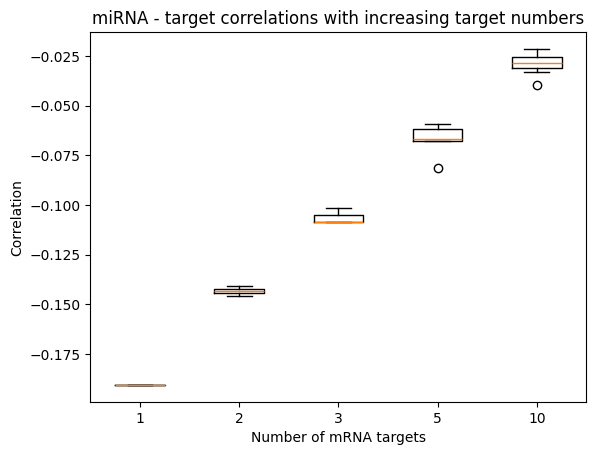

In [304]:
fig, axs = plt.subplots()
axs.boxplot(
    data['corr_miRNA'],
    positions=list(range(len(targets_list)))
)
axs.set_xticklabels(targets_list)
axs.set_xlabel("Number of mRNA targets")
axs.set_ylabel("Correlation")
axs.set_title("miRNA - target correlations with increasing target numbers")
plt.show()

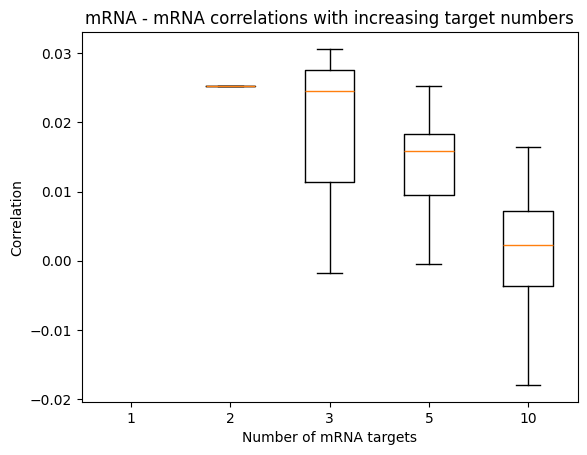

In [305]:
fig, axs = plt.subplots()
axs.boxplot(
    data['corr_mRNA'],
    positions=list(range(len(targets_list)))
)
axs.set_xticklabels(targets_list)
axs.set_xlabel("Number of mRNA targets")
axs.set_ylabel("Correlation")
axs.set_title("mRNA - mRNA correlations with increasing target numbers")
plt.show()

### Stronger interaction

- shows even stronger decrease in correlation as number of targets increase

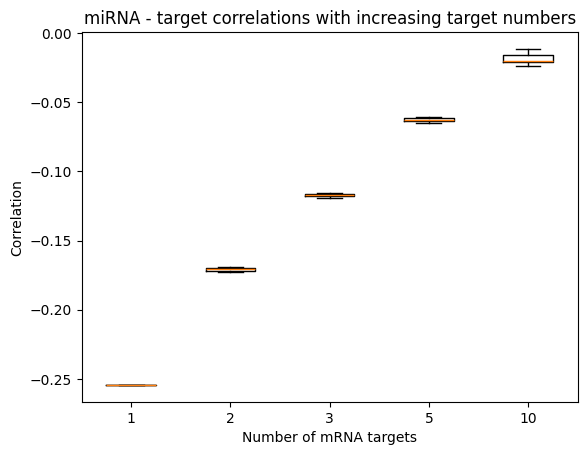

In [307]:
fig, axs = plt.subplots()
axs.boxplot(
    data['corr_miRNA'],
    positions=list(range(len(targets_list)))
)
axs.set_xticklabels(targets_list)
axs.set_xlabel("Number of mRNA targets")
axs.set_ylabel("Correlation")
axs.set_title("miRNA - target correlations with increasing target numbers")
plt.show()

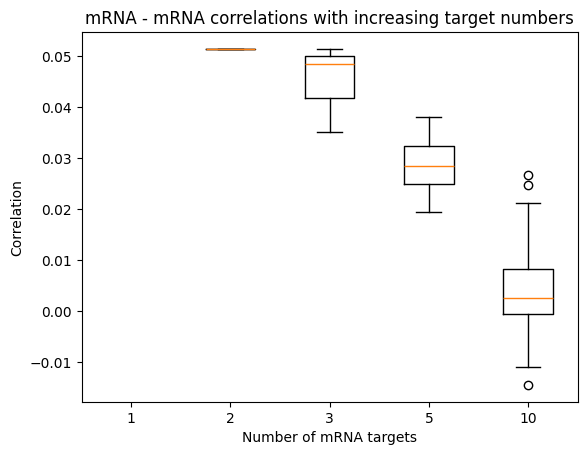

In [308]:
fig, axs = plt.subplots()
axs.boxplot(
    data['corr_mRNA'],
    positions=list(range(len(targets_list)))
)
axs.set_xticklabels(targets_list)
axs.set_xlabel("Number of mRNA targets")
axs.set_ylabel("Correlation")
axs.set_title("mRNA - mRNA correlations with increasing target numbers")
plt.show()

#### Uniform sample time

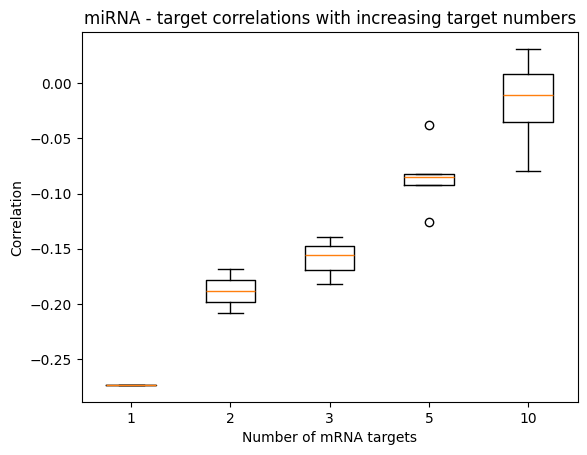

In [309]:
fig, axs = plt.subplots()
axs.boxplot(
    data['sampled_corr_miRNA'],
    positions=list(range(len(targets_list)))
)
axs.set_xticklabels(targets_list)
axs.set_xlabel("Number of mRNA targets")
axs.set_ylabel("Correlation")
axs.set_title("miRNA - target correlations with increasing target numbers")
plt.show()

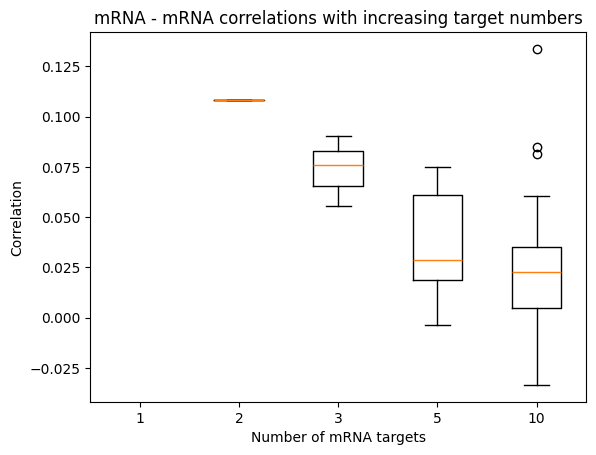

In [311]:
fig, axs = plt.subplots()
axs.boxplot(
    data['sampled_corr_mRNA'],
    positions=list(range(len(targets_list)))
)
axs.set_xticklabels(targets_list)
axs.set_xlabel("Number of mRNA targets")
axs.set_ylabel("Correlation")
axs.set_title("mRNA - mRNA correlations with increasing target numbers")
plt.show()

# M + R -> R

In [266]:
targets = 10

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
stoch_inp[1, 0] = 1

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    stoch_inp[r + 1, s] = 1

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    stoch_out[r + 2, 0] = 1

In [267]:
tmax = 10000

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

In [268]:
tmin = 10
tint = 10

sampled_path = uniform_time_samples(path, path_times, tmin, tint)

Taking 999 uniform time samples


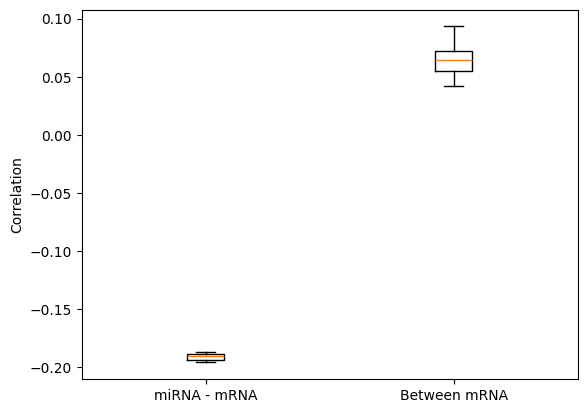

In [269]:
# sampling at reaction times
corr_miRNA, corr_mRNA = correlation_point(path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

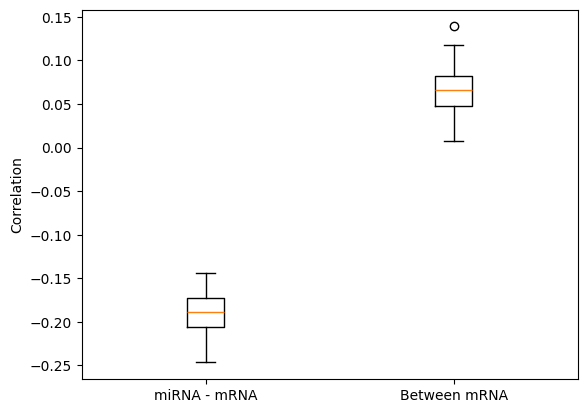

In [270]:
# samping at uniform times
corr_miRNA, corr_mRNA = correlation_point(sampled_path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

In [251]:
# bootstrap CIs
#corr_int_miRNA, corr_int_mRNA = correlation_bootstrap(path)

# correlation between miRNA and targets
#print(corr_int_miRNA)

# correlation between mRNA
#print(corr_int_mRNA)

## Stronger interaction

In [294]:
targets = 10

stoch_inp = np.zeros((2 + targets * 3, 1 + targets))
stoch_out = np.zeros((2 + targets * 3, 1 + targets))
rates = np.ones(2 + 3 * targets)

# miRNA tx and deg reactions
stoch_out[0, 0] = 1
stoch_inp[1, 0] = 1

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    # mRNA tx and deg reactions
    stoch_out[r, s] = 1
    stoch_inp[r + 1, s] = 1

    # miRNA - mRNA interaction
    stoch_inp[r + 2, 0] = 1
    stoch_inp[r + 2, s] = 1
    stoch_out[r + 2, 0] = 1
    rates[r + 2] = 10

In [295]:
tmax = 10000

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

In [296]:
tmin = 10
tint = 10

sampled_path = uniform_time_samples(path, path_times, tmin, tint)

Taking 999 uniform time samples


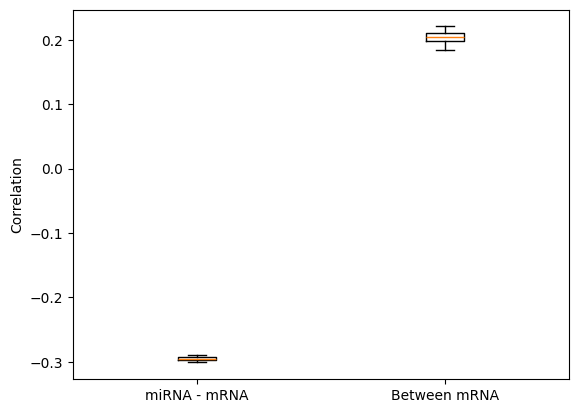

In [297]:
# sampling at reaction times
corr_miRNA, corr_mRNA = correlation_point(path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

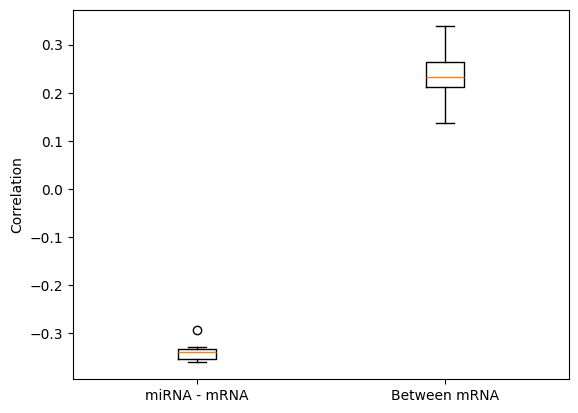

In [298]:
# samping at uniform times
corr_miRNA, corr_mRNA = correlation_point(sampled_path)

# display
fig, axs = plt.subplots()
axs.boxplot([corr_miRNA, corr_mRNA], positions=[0, 1])
axs.set_xticklabels({"miRNA - mRNA", "Between mRNA"})
axs.set_ylabel("Correlation")
plt.show()

# Summary

M + R -> 0

- weak correlations, both between miRNA and targets and between mRNA
    - very slight increase in correlation with interaction strength
        - maybe more if more miRNA?
        - too many mRNA competing for limited miRNA?
    - faster miRNA timescale (but same expression) gives small increase in correlations
    - higher miRNA expression (not observed in real data) gives moderate increase in correlations
- correlations steadily reduce in magnitude as the number of targets are increased, reaching close to 0 for just 10 targets (with slightly stronger interaction)
    - whereas in real data observe (small) negative correlations for 100 - 1000s of targets

M + R -> R

- stronger correlations even for low interaction strength than highest of above
- stronger interaction means stronger correlation

# Appendix

## Uniform time point samples?

Gillespie produces a 'step function' of reaction times where the system state changes its value, then remains there until the next reaction

Could take the states at each reaction time, but this may be unrealistic and could instead take the state at a uniformly spaced set of times (as a step function)

Results (see below)
- uniform times seem to have more negative correlations than reaction times

In [ ]:
stoch_inp = np.array([
    [0, 0],
    [0, 0],
    [1, 0],
    [0, 1],
    [1, 1]
])

stoch_out = np.array([
    [1, 0],
    [0, 1],
    [0, 0],
    [0, 0],
    [1, 0]
])

rates = np.array([
    5,
    5,
    1,
    1,
    1
])

tmax = 1000
tmin = 10
tint = 10

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

In [ ]:
sampled_path = uniform_time_samples(path, path_times, tmin, tint)

Taking 99 uniform time samples


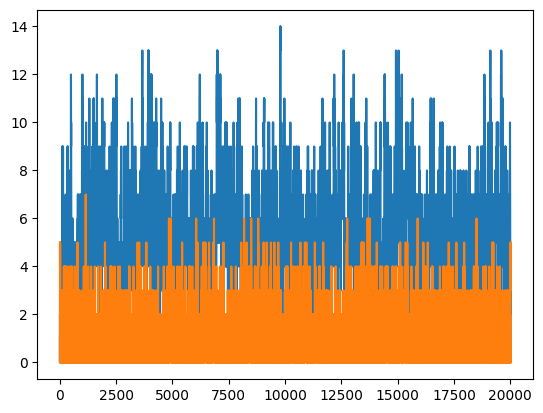

In [126]:
plt.plot(path[:, 0])
plt.plot(path[:, 1])

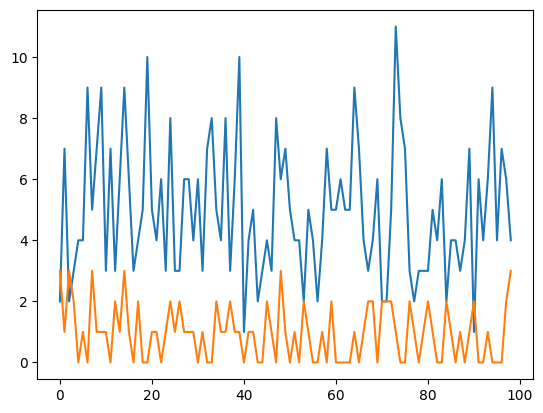

In [127]:
plt.plot(sampled_path[:, 0])
plt.plot(sampled_path[:, 1])

In [128]:
np.corrcoef(path.T)[0, 1]

np.float64(-0.2574574800405149)

In [129]:
np.corrcoef(sampled_path.T)[0, 1]

np.float64(-0.2537015024706938)

In [130]:
repeats = 10
corr_path = []
corr_sampled = []
for _ in range(repeats):
    path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)
    sampled_path = uniform_time_samples(path, path_times, tmin, tint)
    corr_path.append(np.corrcoef(path.T)[0, 1])
    corr_sampled.append(np.corrcoef(sampled_path.T)[0, 1])

Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples


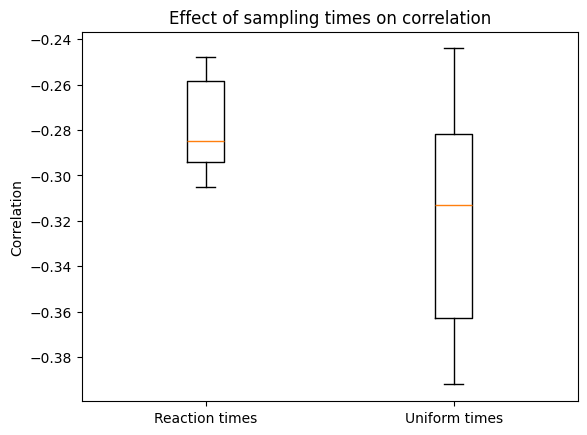

In [141]:
fig, axs = plt.subplots()
axs.boxplot([corr_path, corr_sampled], positions=[0, 1])
axs.set_xticklabels(["Reaction times", "Uniform times"])
axs.set_ylabel("Correlation")
axs.set_title("Effect of sampling times on correlation")
plt.show()